# PycWB Tutorial

## 1. Run your first example

First, we download the example user parameter file

In [1]:
import os

import pycwb
from pycwb.config import Config
from pycwb.modules.logger import logger_init

logger_init()

config = Config()
config.load_from_yaml('./user_parameters.yaml')

Welcome to JupyROOT 6.26/10
Loading wavelet library
Trying to load wavelet library from /Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/lib/wavelet.so




/Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/ROOT/_facade.py:153: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _orig_ihook(name, *args, **kwds)


25-11-29 20:26:43 - logger_init - INFO - Logging initialized
25-11-29 20:26:43 - logger_init - INFO - Logging level: INFO
25-11-29 20:26:43 - logger_init - INFO - Logging file: None
25-11-29 20:26:43 - check_MRA_catalog - INFO - Checking MRA catalog
25-11-29 20:26:43 - load_MRA - INFO - Loading catalog of WDM cross-talk coefficients: ../../data/wdmXTalk/OverlapCatalog16-1024.bin


generate injected data for each detector with given parameters in config

In [2]:
from pycwb.modules.read_data import read_from_catalog, read_from_online
from gwpy.timeseries import TimeSeries

import requests
from gwosc.locate import get_urls
t0 = 1126259462.4

framefiles = {
  'H1': '../../data/framefiles/H-H1_GWOSC_4KHZ_R1-1126257415-4096.hdf5',
  'L1': '../../data/framefiles/L-L1_GWOSC_4KHZ_R1-1126257415-4096.hdf5',
}

data = []
for ifo in config.ifo:
  strain = TimeSeries.read(framefiles[ifo],format='hdf5.gwosc')
  d = strain.crop(t0-150, t0+150)
  d_resampled = d.resample(2048)
  data.append(d_resampled)

apply data conditioning to the data

25-11-29 20:26:50 - whitening_cwb - INFO - WDM filter max length = 6.00048828125 (sec)
25-11-29 20:26:50 - whitening_cwb - INFO - WDM filter max length = 6.00048828125 (sec)
25-11-29 20:26:50 - data_conditioning - INFO - -------------------------------------------------------
25-11-29 20:26:50 - data_conditioning - INFO - Data Conditioning Time: 2.10 seconds
25-11-29 20:26:50 - data_conditioning - INFO - -------------------------------------------------------


((<pycwb.types.time_frequency_series.TimeFrequencySeries at 0x1d097fd10>,
  <pycwb.types.time_frequency_series.TimeFrequencySeries at 0x1d097fed0>),
 (<pycwb.types.time_frequency_series.TimeFrequencySeries at 0x1d097fe60>,
  <pycwb.types.time_frequency_series.TimeFrequencySeries at 0x1d09e0120>))

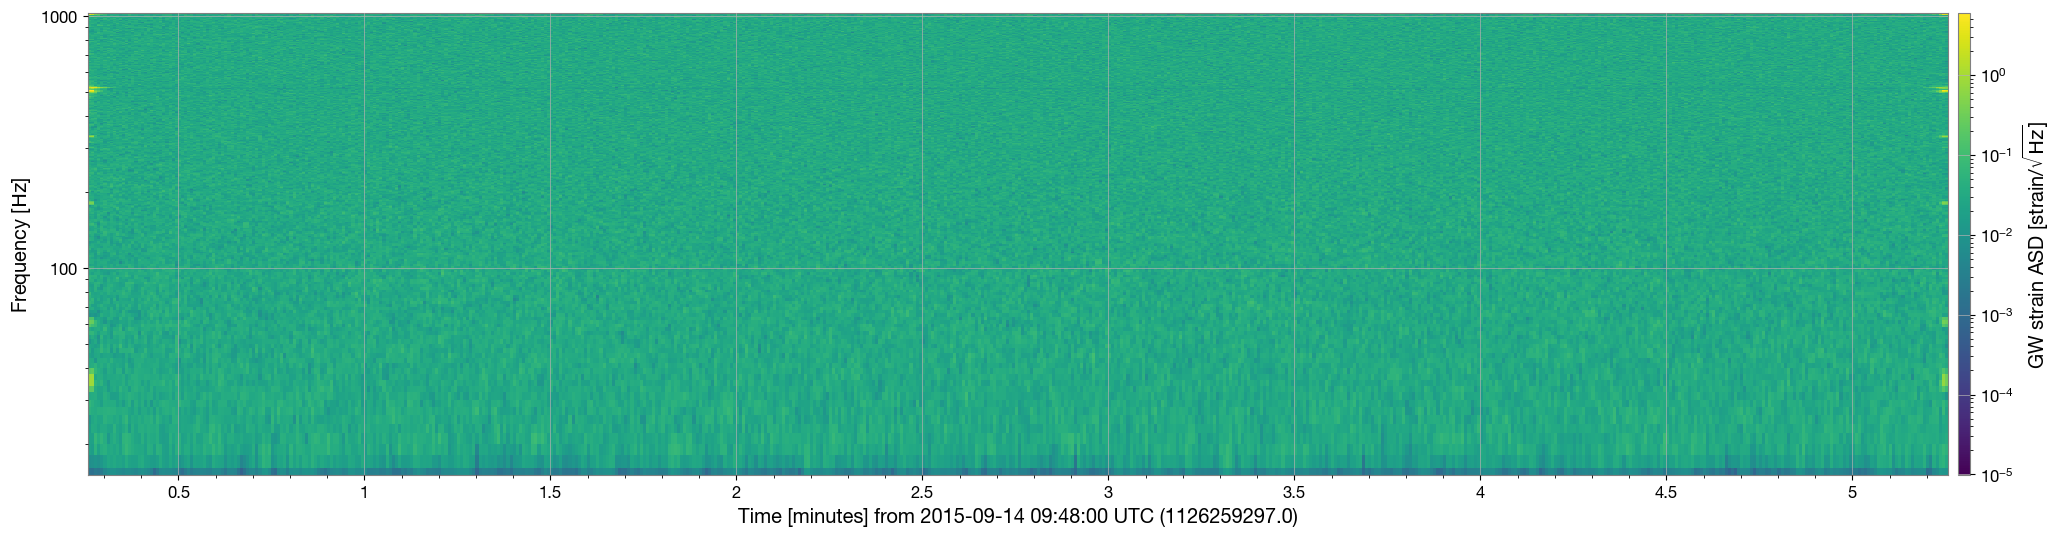

In [3]:
from pycwb.modules.data_conditioning import data_conditioning
from pycwb.modules.plot import plot_spectrogram

strains, nRMS = data_conditioning(config, data)

%matplotlib inline

# plot the spectrogram for L1
plt = plot_spectrogram(strains[0], gwpy_plot=True)
ax = plt.gca()
ax.set_ylim(15,1024)

strains, nRMS

calculate coherence

In [4]:
from pycwb.modules.coherence import coherence

# calculate coherence
fragment_clusters = coherence(config, strains, nRMS)

25-11-29 20:26:54 - coherence - INFO - 
25-11-29 20:26:56 - coherence_single_res - INFO - level : 10	 rate(hz) : 2	 layers : 1024	 df(hz) : 1.000000	 dt(ms) : 500.000000 
max energy in units of noise variance: 8.66994 
thresholds in units of noise variance: Eo=8.67942 Emax=17.3588 
live time in zero lag: 280 
lag | clusters | pixels 
  0 |        3 |     27 
Coherence time for single level: 1.956582 s
25-11-29 20:26:58 - coherence_single_res - INFO - level : 9	 rate(hz) : 4	 layers : 512	 df(hz) : 2.000000	 dt(ms) : 250.000000 
max energy in units of noise variance: 8.73875 
thresholds in units of noise variance: Eo=8.64409 Emax=17.2882 
live time in zero lag: 280 
lag | clusters | pixels 
  0 |        7 |     65 
Coherence time for single level: 1.550290 s
25-11-29 20:26:59 - coherence_single_res - INFO - level : 8	 rate(hz) : 8	 layers : 256	 df(hz) : 4.000000	 dt(ms) : 125.000000 
max energy in units of noise variance: 8.9771 
thresholds in units of noise variance: Eo=8.6361 Emax=17

In [17]:
fragment_clusters[0][0]

FragmentCluster(rate=2048.0, start=1126259312.3999023, stop=1126259612.3999023, bpp=1.0, shift=0.0, f_low=16.0, f_high=1024.0, n_pix=3, run=0, pair=1, subnet_threshold=2.3167399999982425, clusters=[Cluster(pixels=[Pixel(time=215006, frequency=781, layers=1025, rate=2.0, likelihood=16.063457489013672, null=-5.081990888372664e-22, theta=-1.0, phi=1.0, ellipticity=0.0, polarisation=0.0, core=1, data=[PixelData(noise_rms=3.930072508806473e-22, wave=0.0, w_90=0.0, asnr=3.2800290932396194, a_90=0.0, rank=0.0, index=215006), PixelData(noise_rms=4.556421537973451e-22, wave=0.0, w_90=0.0, asnr=2.303229648556494, a_90=0.0, rank=0.0, index=215006)], td_amp=array([], dtype=float64), neighbors=[1]), Pixel(time=216032, frequency=782, layers=1025, rate=2.0, likelihood=17.831361770629883, null=-5.081990888372664e-22, theta=-1.0, phi=1.0, ellipticity=0.0, polarisation=0.0, core=1, data=[PixelData(noise_rms=4.734533872118854e-22, wave=0.0, w_90=0.0, asnr=3.4536002414047506, a_90=0.0, rank=0.0, index=216

In [19]:
# %matplotlib inline
# from gwpy.spectrogram import Spectrogram
# for fragment_cluster in fragment_clusters:
#   for cluster in fragment_cluster[0].clusters:
#       merged_map, start, dt, df = cluster.get_sparse_map("likelihood")

#       plt = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()
#       plt.colorbar()

supercluster

In [6]:
from pycwb.modules.super_cluster import supercluster
from pycwb.types.network import Network

network = Network(config, strains, nRMS)

pwc_list = supercluster(config, network, fragment_clusters, strains)

25-11-29 20:27:05 - set_time_shift - INFO - lag step: 1.0
25-11-29 20:27:05 - set_time_shift - INFO - number of time lags: 1
25-11-29 20:27:06 - sparse_table_from_fragment_clusters - INFO - ----------------------------------------
25-11-29 20:27:06 - sparse_table_from_fragment_clusters - INFO - Sparse series time: 0.59 s
25-11-29 20:27:06 - sparse_table_from_fragment_clusters - INFO - ----------------------------------------
25-11-29 20:27:07 - supercluster - INFO - -> Processing lag=0 ...
25-11-29 20:27:07 - supercluster - INFO -    --------------------------------------------------
25-11-29 20:27:07 - supercluster - INFO -     coher clusters|pixels      :     82|985
25-11-29 20:27:07 - supercluster - INFO -     super clusters|pixels      :     69|985
25-11-29 20:27:07 - supercluster - INFO -    defrag clusters|pixels      :     67|985
25-11-29 20:27:07 - supercluster - INFO -    subnet clusters|pixels      :      1|325
25-11-29 20:27:07 - supercluster - INFO - Supercluster done
25-11

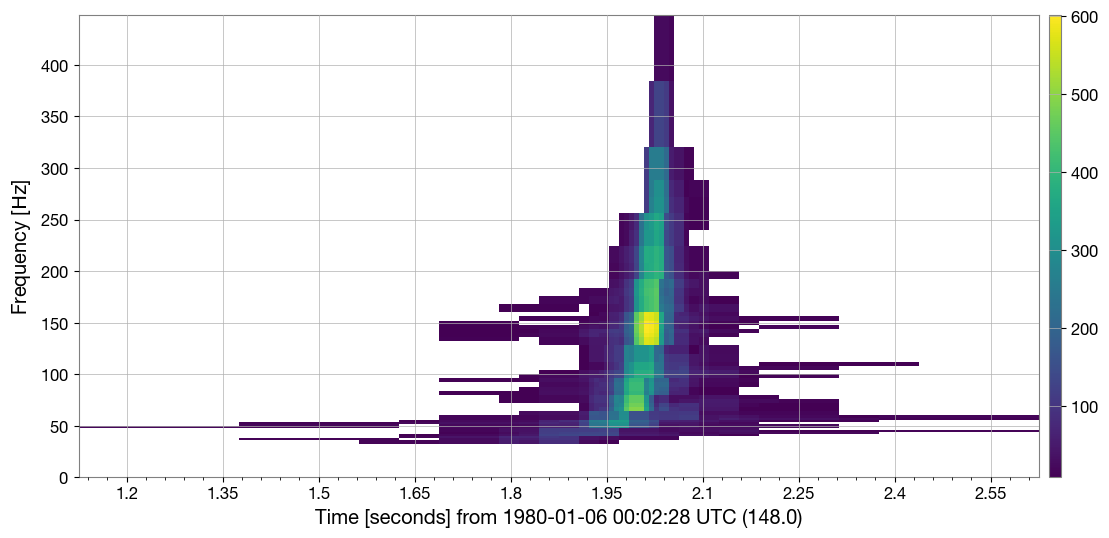

In [7]:
%matplotlib inline
from gwpy.spectrogram import Spectrogram

for cluster in pwc_list[0].clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("likelihood")

    plt = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()
    plt.colorbar()

Likelihood

In [8]:
from pycwb.modules.likelihood import likelihood

events, clusters, skymap_statistics = likelihood(config, network, pwc_list)

25-11-29 20:27:10 - likelihood - WARNING - The support of list type is only for backward compatibility. It will be deprecated in the future.
25-11-29 20:27:10 - likelihood - INFO - -------------------------------------------------------
25-11-29 20:27:10 - likelihood - INFO - -> Processing 1 clusters in lag=0
25-11-29 20:27:10 - likelihood - INFO -    ----------------------------------------------------
25-11-29 20:27:14 - _likelihood - INFO - Selected core pixels: 1
25-11-29 20:27:14 - _likelihood - INFO -    cluster-id|pixels:     1|325
25-11-29 20:27:14 - _likelihood - INFO - 	 -> SELECTED !!!
25-11-29 20:27:14 - likelihood - INFO - -------------------------------------------------------
25-11-29 20:27:14 - likelihood - INFO - Total events: 1
25-11-29 20:27:14 - likelihood - INFO - Total time: 3.50 s
25-11-29 20:27:14 - likelihood - INFO - -------------------------------------------------------
Eo = 2262.39, Lo = 2116.99, Ep = 666.159, Lp = 622.78
q[0][393]: 0.000000, p[0][393]: 0.0

plot statistics

/Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/gwpy/plot/plot.py:297: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  super().show(warn=warn)


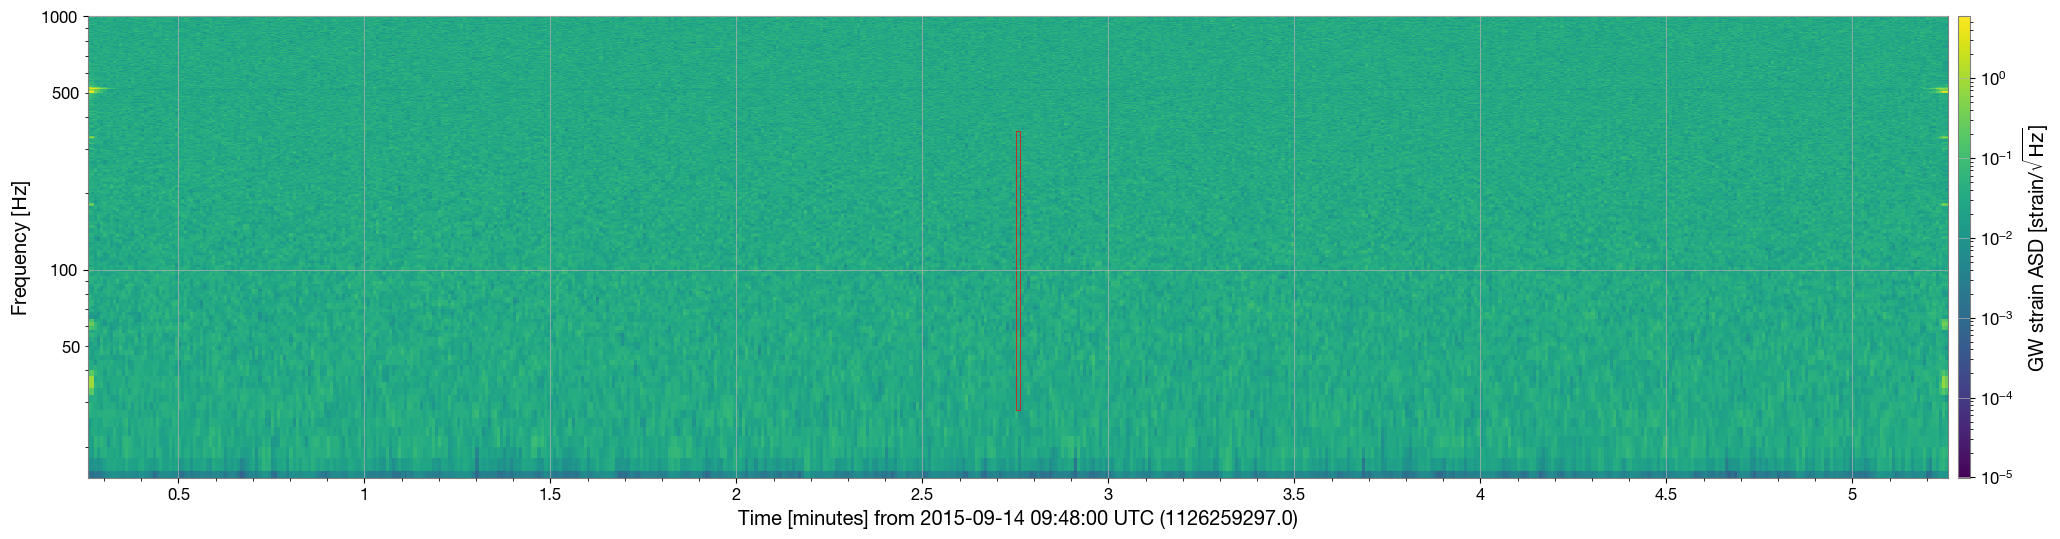

In [9]:
%matplotlib inline
from pycwb.modules.plot import plot_event_on_spectrogram

plt = plot_event_on_spectrogram(strains[0], events)
plt.show()

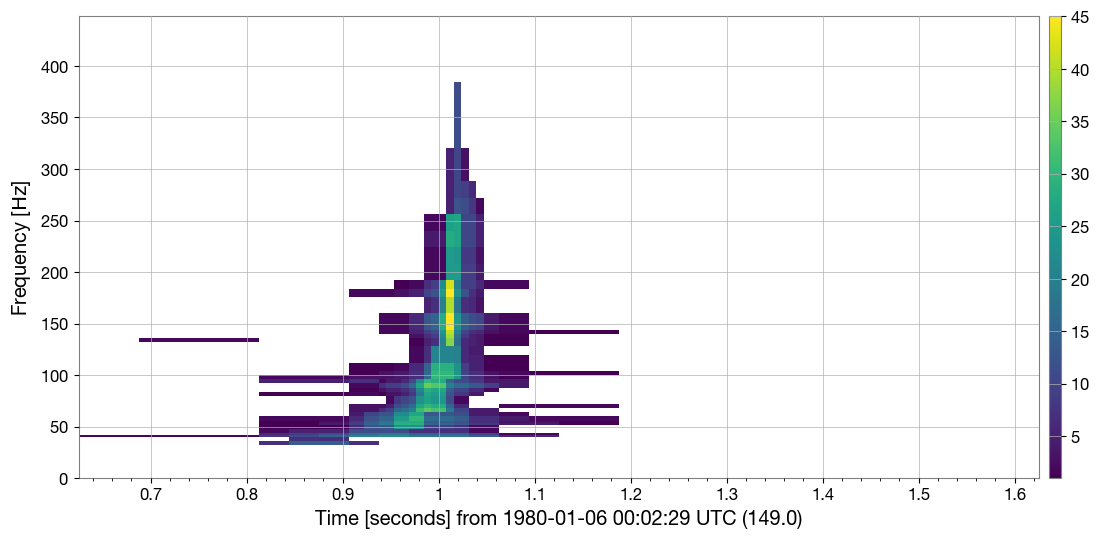

In [10]:
%matplotlib inline
from gwpy.spectrogram import Spectrogram

for cluster in clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("likelihood")

    plt = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()
    plt.colorbar()

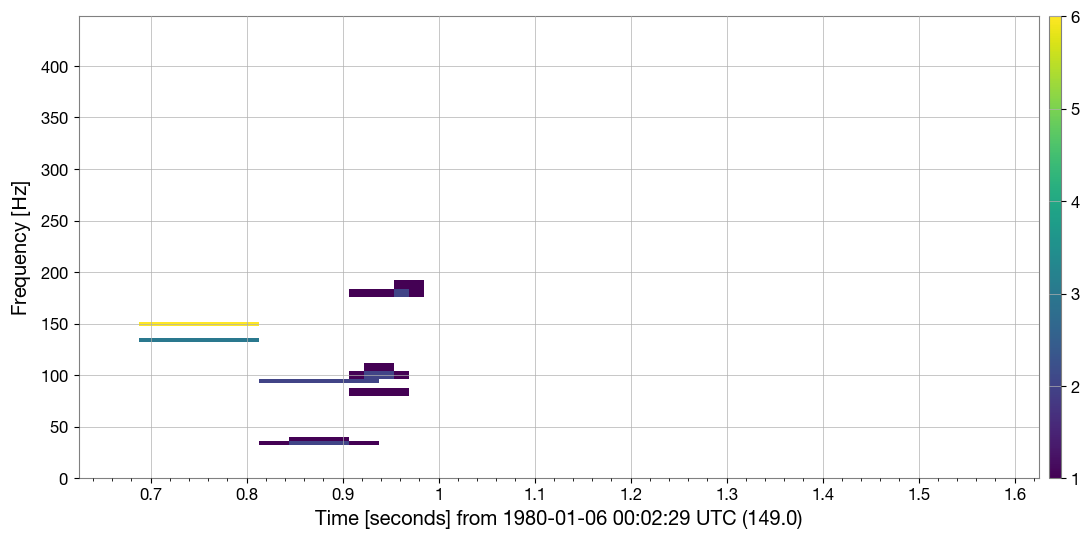

In [11]:
%matplotlib inline
from gwpy.spectrogram import Spectrogram

for cluster in clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("null")

    plt = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()
    plt.colorbar()

(149.75, 150.25)

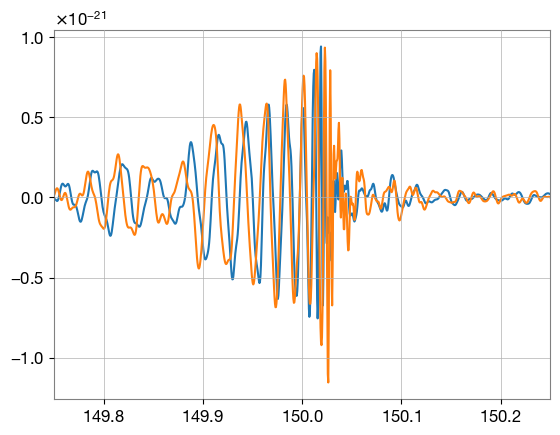

In [12]:
from pycwb.modules.reconstruction import get_network_MRA_wave
from pycwb.modules.plot.waveform import plot_reconstructed_waveforms
from matplotlib import pyplot as plt

event = events[0]
cluster = clusters[0]
reconstructed_waves = get_network_MRA_wave(config, cluster, config.rateANA, config.nIFO, config.TDRate,
                                               'signal', 0, True)
for reconstructed_wave in reconstructed_waves:
  plt.plot(reconstructed_wave.sample_times, reconstructed_wave.data)
plt.xlim((event.left[0], event.left[0] + event.stop[0] - event.start[0]))

In [13]:
events

[Event(nevent=1, ndim=2, run=0, rho=[16.82819938659668, 16.205471887395742, 0], netcc=[0.9294506311416626, 0.9294506311416626, 0.9142906069755554, 0.9254576563835144], neted=[-3.0662155151367188, 88.620361328125, 701.7325439453125, 708.4895629882812, 2262.385986328125], gnet=0.5499611496925354, anet=0.14632120728492737, inet=0.0, ecor=566.3797607421875, norm=6.398651599884033, ECOR=566.3766479492188, penalty=0.9620796923637083, likelihood=641.0654296875, factor=0.0, range=[0], chirp=[0, 36.999935150146484, 2.2268567085266113, 0.9884099960327148, 0.8796992301940918, 0.9492351412773132], eBBH=[], usize=0.0, ifo_list=[], eventID=[1, 0], type=[1], name=[], log=[], rate=[0, 0], volume=[325, 133], size=[135, 135], gap=[0, 0], lag=[0.0, 0.0, 0.0, 0.0], slag=(0, 0, 0), strain=[6.759318677776091e-45], phi=[353.8636363636364, 0, 134.62930895085447, 291.796875], theta=[155.69633519657742, 0, -65.69633519657742, 156.44354248046875], psi=[0.0], iota=[0.0], bp=[-0.5329943957257304, 0.790965069582707